# Task 1: Inductive Biases and Representations



## 0. Setup

In [ ]:
%pip -q install open_clip_torch scikit-learn pandas matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00


In [ ]:
import csv, gc, json, random, subprocess, sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageDraw
from IPython.display import display, Markdown
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import STL10
from torchvision.models import resnet50, vit_b_16, ResNet50_Weights, ViT_B_16_Weights
from torchvision.transforms import functional as TF, InterpolationMode
from sklearn.metrics import accuracy_score, f1_score
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import open_clip, torchvision, sklearn

SEED=6304
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark=False
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
assert DEVICE=='cuda', 'Select a Colab GPU runtime before continuing.'
OUT=Path('/content/task1_results'); OUT.mkdir(parents=True,exist_ok=True)
DATA=Path('/content/stl10_data'); DATA.mkdir(parents=True,exist_ok=True)
BATCH=64
CLASSES=['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']
NAMES=['ResNet-50','ViT-B/16','CLIP head','CLIP zero-shot']
PAIRS=[('airplane','ship'),('bird','cat'),('deer','horse'),('dog','monkey'),('car','truck')]
HUE_DEGREES=90
ADA_ALPHA=0.8
VIS_N=100
print(f'Device: {DEVICE} | torch {torch.__version__} | torchvision {torchvision.__version__} | open_clip {getattr(open_clip,"__version__","unknown")} | sklearn {sklearn.__version__}')
print('Output:', OUT)

Device: cuda | torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | open_clip 3.3.0 | sklearn 1.6.1
Output: /content/task1_results


In [ ]:
config=dict(seed=SEED,dataset='STL10',size=224,resize='PIL bicubic',split='stratified 80/20 official train',
    models={'ResNet-50':'ResNet50_Weights.IMAGENET1K_V2','ViT-B/16':'ViT_B_16_Weights.IMAGENET1K_V1','CLIP':'ViT-B-32 pretrained=openai'},
    head=dict(optimizer='AdamW',lr=1e-3,weight_decay=1e-4,max_epochs=50,patience=5,selection='validation accuracy'),
    prompt='a photo of a {class}.',hue_degrees=HUE_DEGREES,adain_alpha=ADA_ALPHA,pairs=PAIRS,
    translation=[0,8,16,32],patch_grid=[4,4],visualization=dict(method='t-SNE',seed=SEED,n=VIS_N,perplexity=30,metric='cosine',init='pca',learning_rate='auto'))
(OUT/'config.json').write_text(json.dumps(config,indent=2))

1022

## 1. Data and frozen features

In [ ]:
train_ds=STL10(root=str(DATA),split='train',download=True)
test_ds=STL10(root=str(DATA),split='test',download=True)
assert list(train_ds.classes)==CLASSES, (train_ds.classes,CLASSES)
y_train=np.asarray(train_ds.labels,dtype=np.int64); y_test=np.asarray(test_ds.labels,dtype=np.int64)
tr_idx,va_idx=train_test_split(np.arange(len(train_ds)),test_size=0.2,stratify=y_train,random_state=SEED)
rng=np.random.default_rng(SEED)
selected=[]; shortage={}
for c in range(10):
    pool=np.flatnonzero(y_test==c)
    k=min(50,len(pool)); shortage[CLASSES[c]]=50-k
    selected.extend(rng.choice(pool,k,replace=False).tolist())
selected=np.asarray(selected,dtype=np.int64)
assert len(selected)==len(set(selected))
assert all(y_test[selected].tolist().count(c)==min(50,int(sum(y_test==c))) for c in range(10))
pd.DataFrame({'selected_order':np.arange(len(selected)), 'official_test_index':selected,
              'image_id':['STL10-test-%05d'%i for i in selected], 'class_id':y_test[selected],
              'class_name':[CLASSES[c] for c in y_test[selected]]}).to_csv(OUT/'selected_test_ids.csv',index=False)
(OUT/'train_val_ids.json').write_text(json.dumps({'train_official_indices':tr_idx.tolist(),'val_official_indices':va_idx.tolist()}))
print('Train / validation / test subset:',len(tr_idx),len(va_idx),len(selected))
print('Test counts:',pd.Series(y_test[selected]).value_counts().sort_index().rename(index=dict(enumerate(CLASSES))).to_dict())
print('Shortfall from 50 per class:',shortage)

def common(image):
    return np.asarray(image.convert('RGB').resize((224,224),Image.Resampling.BICUBIC),dtype=np.uint8)
def subset_images(ds, ids):
    return np.stack([common(ds[int(i)][0]) for i in tqdm(ids,desc='Resize')])
Xtr=subset_images(train_ds,tr_idx); Xva=subset_images(train_ds,va_idx)
X=subset_images(test_ds,selected); y=y_test[selected]
assert X.shape[1:]==(224,224,3) and X.dtype==np.uint8
np.savez_compressed(OUT/'clean_subset.npz',images=X,official_indices=selected,labels=y)
print('Common pixels:',X.shape)

100%|██████████| 2.64G/2.64G [04:15<00:00, 10.3MB/s]


Train / validation / test subset: 4000 1000 500
Test counts: {'airplane': 50, 'bird': 50, 'car': 50, 'cat': 50, 'deer': 50, 'dog': 50, 'horse': 50, 'monkey': 50, 'ship': 50, 'truck': 50}
Shortfall from 50 per class: {'airplane': 0, 'bird': 0, 'car': 0, 'cat': 0, 'deer': 0, 'dog': 0, 'horse': 0, 'monkey': 0, 'ship': 0, 'truck': 0}


Resize:   0%|          | 0/4000 [00:00<?, ?it/s]

Resize:   0%|          | 0/1000 [00:00<?, ?it/s]

Resize:   0%|          | 0/500 [00:00<?, ?it/s]

Common pixels: (500, 224, 224, 3)


In [ ]:
RW = ResNet50_Weights.IMAGENET1K_V2
VW = ViT_B_16_Weights.IMAGENET1K_V1

from open_clip.pretrained import get_pretrained_cfg
clip_cfg = get_pretrained_cfg('ViT-B-32', 'openai')
assert 'mean' in clip_cfg and 'std' in clip_cfg

NORMALIZATIONS = {
    'ResNet-50': RW.transforms(),
    'ViT-B/16': VW.transforms(),
    'CLIP head': torchvision.transforms.Normalize(
        mean=clip_cfg['mean'], std=clip_cfg['std']
    ),
}
print({k: (v.mean, v.std) for k, v in NORMALIZATIONS.items()})

class ResNetFeatures(nn.Module):
    def __init__(self):
        super().__init__(); self.net=resnet50(weights=RW); self.net.fc=nn.Identity()
    def forward(self,x): return self.net(x)
class ViTFeatures(nn.Module):
    def __init__(self): super().__init__(); self.net=vit_b_16(weights=VW)
    def forward(self,x):
        m=self.net; z=m._process_input(x)
        z=torch.cat((m.class_token.expand(z.shape[0],-1,-1),z),dim=1)
        return m.encoder(z)[:,0]
class CLIPFeatures(nn.Module):
    def __init__(self):
        super().__init__()
        self.net, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai', force_quick_gelu=True)
    def forward(self,x): return F.normalize(self.net.encode_image(x).float(),dim=-1)
def make_model(name):
    model={'ResNet-50':ResNetFeatures,'ViT-B/16':ViTFeatures,'CLIP head':CLIPFeatures}[name]().to(DEVICE).eval()
    for p in model.parameters(): p.requires_grad_(False)
    return model

def features(model,name,images,batch=BATCH):
    norm=NORMALIZATIONS[name]
    mean=torch.tensor(norm.mean,device=DEVICE).view(1,3,1,1)
    std=torch.tensor(norm.std,device=DEVICE).view(1,3,1,1)
    result=[]
    with torch.inference_mode():
        for start in range(0,len(images),batch):
            t=torch.from_numpy(np.ascontiguousarray(images[start:start+batch])).to(DEVICE)
            t=(t.permute(0,3,1,2).float()/255-mean)/std
            result.append(model(t).float().cpu().numpy())
    return np.concatenate(result)
assert len(Xtr)==4000 and len(Xva)==1000
print('Feature extraction is frozen; only the linear heads will train.')

{'ResNet-50': ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]), 'ViT-B/16': ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]), 'CLIP head': ((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711))}
Feature extraction is frozen; only the linear heads will train.


In [ ]:
HEADS={}; CLEAN_FEATURES={}; CLEAN_LOGITS={}; HISTORY=[]
for name in ['ResNet-50','ViT-B/16','CLIP head']:
    print('\n',name)
    model=make_model(name)
    ftr=features(model,name,Xtr); fva=features(model,name,Xva); ftest=features(model,name,X)
    assert len(ftr)==len(tr_idx) and len(fva)==len(va_idx) and len(ftest)==len(X)
    assert np.isfinite(ftr).all() and np.isfinite(ftest).all()

    torch.manual_seed(SEED); np.random.seed(SEED)
    head=nn.Linear(ftr.shape[1],10).to(DEVICE)
    opt=torch.optim.AdamW(head.parameters(),lr=1e-3,weight_decay=1e-4)
    a=torch.from_numpy(ftr).to(DEVICE); b=torch.from_numpy(fva).to(DEVICE)
    ya=torch.from_numpy(y_train[tr_idx]).to(DEVICE); yb=torch.from_numpy(y_train[va_idx]).to(DEVICE)
    best=-1.0; stale=0; best_state=None
    for epoch in range(1,51):
        head.train(); gen=torch.Generator().manual_seed(SEED+epoch)
        perm=torch.randperm(len(a),generator=gen).to(DEVICE)
        for ix in perm.split(128):
            opt.zero_grad(set_to_none=True)
            loss=F.cross_entropy(head(a[ix]),ya[ix]); loss.backward(); opt.step()
        head.eval()
        with torch.inference_mode(): score=(head(b).argmax(1)==yb).float().mean().item()
        HISTORY.append(dict(model=name,epoch=epoch,validation_accuracy=score))
        if score>best+1e-12:
            best=score; stale=0; best_state={k:v.detach().cpu().clone() for k,v in head.state_dict().items()}; best_epoch=epoch
        else: stale+=1
        if stale>=5: break
    head.load_state_dict(best_state); head.eval()
    torch.save({'state_dict':best_state,'feature_dim':ftr.shape[1],'best_epoch':best_epoch,
                'val_accuracy':best,'seed':SEED},OUT/(name.replace('/','_').replace(' ','_')+'_head.pt'))
    HEADS[name]=(head.weight.detach().cpu().numpy(),head.bias.detach().cpu().numpy())
    CLEAN_FEATURES[name]=ftest
    CLEAN_LOGITS[name]=ftest@HEADS[name][0].T+HEADS[name][1]
    print(f'best epoch {best_epoch}, validation accuracy {best:.4f}, feature dim {ftr.shape[1]}')
    if name=='CLIP head':
        tokens=open_clip.get_tokenizer('ViT-B-32')([f'a photo of a {c}.' for c in CLASSES]).to(DEVICE)
        with torch.inference_mode():
            txt=F.normalize(model.net.encode_text(tokens).float(),dim=-1).cpu().numpy()
            scale=model.net.logit_scale.exp().detach().float().cpu().item()
        CLEAN_LOGITS['CLIP zero-shot']=scale*(ftest@txt.T)
        print('CLIP logit scale:',scale)
    del model, ftr, fva, ftest, a, b, ya, yb, head, opt
    gc.collect(); torch.cuda.empty_cache()
pd.DataFrame(HISTORY).to_csv(OUT/'head_training.csv',index=False)
assert set(CLEAN_LOGITS)==set(NAMES)
print('All backbones frozen; heads saved.')


 ResNet-50
best epoch 7, validation accuracy 0.9730, feature dim 2048

 ViT-B/16
best epoch 19, validation accuracy 0.9810, feature dim 768

 CLIP head
best epoch 5, validation accuracy 0.9830, feature dim 512
CLIP logit scale: 100.0
All backbones frozen; heads saved.


## 2. Clean baseline

In [ ]:
def probs(logits):
    z=torch.from_numpy(np.asarray(logits,dtype=np.float32))
    return torch.softmax(z,dim=1).numpy()
def summarize(logits,labels,reference=None):
    p=probs(logits); pred=p.argmax(axis=1)
    return dict(accuracy=accuracy_score(labels,pred),macro_f1=f1_score(labels,pred,labels=np.arange(10),average='macro',zero_division=0),
                mean_max_confidence=p.max(axis=1).mean(), consistency=np.nan if reference is None else np.mean(pred==reference))
PRED_CLEAN={m:probs(CLEAN_LOGITS[m]).argmax(1) for m in NAMES}
ROWS=[]
for m in NAMES:
    ROWS.append(dict(model=m,condition='clean',**summarize(CLEAN_LOGITS[m],y)))
def show_table(frame,columns=None):
    display(frame[columns] if columns else frame)
show_table(pd.DataFrame(ROWS).round(4))

,model,condition,accuracy,macro_f1,mean_max_confidence,consistency
0,ResNet-50,clean,0.974,0.9741,0.9091,NaN
1,ViT-B/16,clean,0.974,0.9739,0.9694,NaN
2,CLIP head,clean,0.984,0.9840,0.2150,NaN
3,CLIP zero-shot,clean,0.980,0.9799,0.9548,NaN


## 3. Color interventions

Grayscale:   0%|          | 0/500 [00:00<?, ?it/s]

Hue:   0%|          | 0/500 [00:00<?, ?it/s]

/tmp/ipykernel_1087/597743149.py:6: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return np.asarray(Image.fromarray(hsv,'HSV').convert('RGB'),dtype=np.uint8)


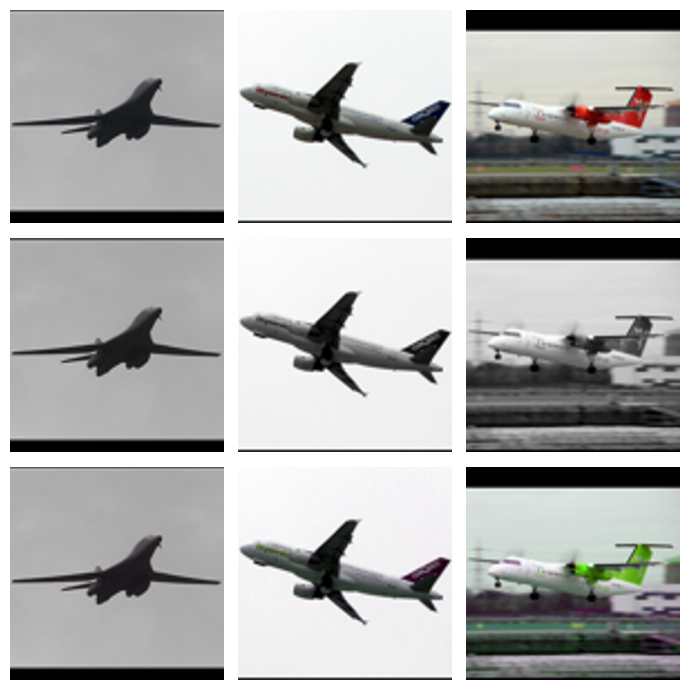

In [ ]:
def grayscale(im):
    return np.asarray(ImageOps.grayscale(Image.fromarray(im)).convert('RGB'),dtype=np.uint8)
def hue_rotate(im):
    hsv=np.asarray(Image.fromarray(im).convert('HSV')).copy()
    hsv[:,:,0]=(hsv[:,:,0].astype(np.uint16)+round(HUE_DEGREES*256/360))%256
    return np.asarray(Image.fromarray(hsv,'HSV').convert('RGB'),dtype=np.uint8)
GRAY=np.stack([grayscale(im) for im in tqdm(X,desc='Grayscale')])
HUE=np.stack([hue_rotate(im) for im in tqdm(X,desc='Hue')])
assert GRAY.shape==HUE.shape==X.shape
fig,ax=plt.subplots(3,3,figsize=(7,7))
for j,img in enumerate([X,GRAY,HUE]):
    for k in range(3): ax[j,k].imshow(img[k]); ax[j,k].axis('off')
for j,label in enumerate(['Clean','Grayscale','Hue +90°']): ax[j,0].set_ylabel(label)
plt.tight_layout(); plt.show()

## 4. Cue Conflict Image Generation

In [ ]:
REPO=Path('/content/pytorch-AdaIN')
if not REPO.exists(): subprocess.run(['git','clone','--quiet','https://github.com/naoto0804/pytorch-AdaIN.git',str(REPO)],check=True)
commit=subprocess.check_output(['git','-C',str(REPO),'rev-parse','HEAD'],text=True).strip()
config['adain_source']='https://github.com/naoto0804/pytorch-AdaIN'; config['adain_commit']=commit
(OUT/'config.json').write_text(json.dumps(config,indent=2))
import urllib.request
weight_paths={}
for key in ['vgg_normalised','decoder']:
    path=OUT/(key+'.pth'); url=f'https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/{key}.pth'
    if not path.exists(): urllib.request.urlretrieve(url,path)
    assert path.stat().st_size>1000000, f'Incomplete AdaIN download: {path}'
    weight_paths[key]=path
sys.path.insert(0,str(REPO))
import net
from function import adaptive_instance_normalization as adain
vgg=net.vgg.to(DEVICE).eval(); dec=net.decoder.to(DEVICE).eval()
vgg.load_state_dict(torch.load(weight_paths['vgg_normalised'],map_location=DEVICE,weights_only=True))
dec.load_state_dict(torch.load(weight_paths['decoder'],map_location=DEVICE,weights_only=True))
vgg=nn.Sequential(*list(vgg.children())[:31]).eval()
for module in (vgg,dec):
    for p in module.parameters(): p.requires_grad_(False)
print('AdaIN commit:',commit)

AdaIN commit: 47950d0e6656a95a80a4b105c4c0f58d38ef785c


In [ ]:
candidate_file=OUT/'cue_candidates.npz'; review_file=OUT/'cue_review.csv'
if not candidate_file.exists():
    rng=np.random.default_rng(SEED)
    candidates=[]; info=[]
    def adain_image(content,style):
        inp=torch.from_numpy(np.ascontiguousarray(content)).to(DEVICE).permute(2,0,1)[None].float()/255
        sty=torch.from_numpy(np.ascontiguousarray(style)).to(DEVICE).permute(2,0,1)[None].float()/255
        with torch.inference_mode():
            cf=vgg(inp); sf=vgg(sty)
            mixed=ADA_ALPHA*adain(cf,sf)+(1-ADA_ALPHA)*cf
            out=dec(mixed).clamp(0,1)[0].permute(1,2,0)
        return (out.mul(255).round().byte().cpu().numpy())
    for ca,cb in PAIRS:
        for content_class,style_class in [(ca,cb),(cb,ca)]:
            pool=np.flatnonzero(y==CLASSES.index(content_class))
            styles=np.flatnonzero(y==CLASSES.index(style_class))
            assert len(pool)>=40 and len(styles)>=1, 'Not enough selected STL-10 examples for candidate generation.'
            for content_id in tqdm(rng.choice(pool,40,replace=False),desc=f'{content_class} → {style_class}'):
                style_id=int(rng.choice(styles)); candidate_id=len(candidates)
                candidates.append(adain_image(X[content_id],X[style_id]))
                info.append(dict(candidate_id=candidate_id,content_id=int(content_id),style_id=style_id,
                    content_class=content_class,style_class=style_class))
    np.savez_compressed(candidate_file,images=np.stack(candidates))
    pd.DataFrame(info).assign(accept='').to_csv(review_file,index=False)
assert candidate_file.exists() and review_file.exists()
CAND=np.load(candidate_file)['images']; review=pd.read_csv(review_file,dtype={'accept':'string'},keep_default_na=False)
assert len(CAND)==len(review)==400
print('Generated candidates:',len(CAND),'| review:',review_file)

airplane → ship:   0%|          | 0/40 [00:00<?, ?it/s]

ship → airplane:   0%|          | 0/40 [00:00<?, ?it/s]

bird → cat:   0%|          | 0/40 [00:00<?, ?it/s]

cat → bird:   0%|          | 0/40 [00:00<?, ?it/s]

deer → horse:   0%|          | 0/40 [00:00<?, ?it/s]

...

dog → monkey:   0%|          | 0/40 [00:00<?, ?it/s]

monkey → dog:   0%|          | 0/40 [00:00<?, ?it/s]

car → truck:   0%|          | 0/40 [00:00<?, ?it/s]

truck → car:   0%|          | 0/40 [00:00<?, ?it/s]

Generated candidates: 400 | review: /content/task1_results/cue_review.csv


Contact sheets: /content/task1_results/cue_contact_sheets (40 pages, 10 triplets each).


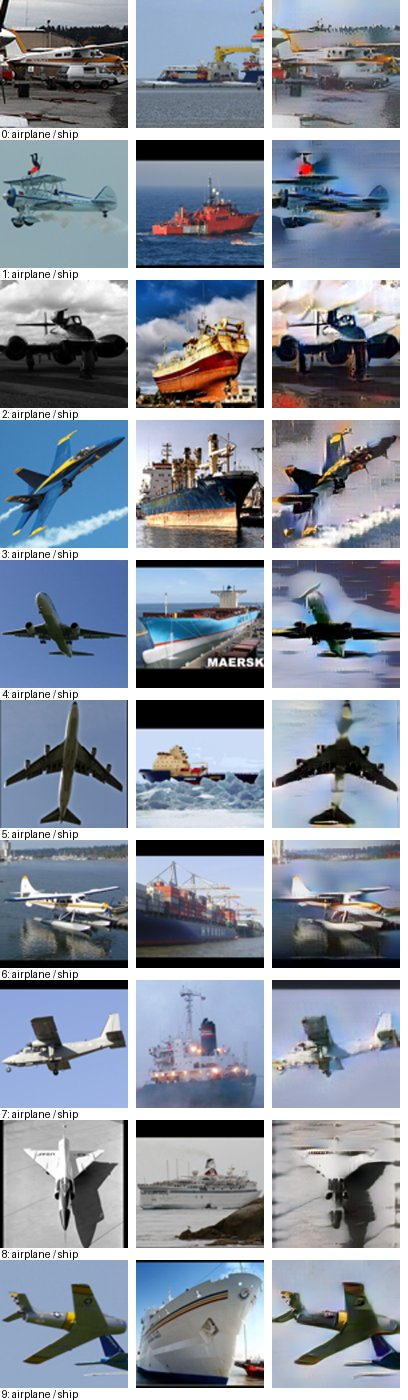

In [ ]:
SHEET=OUT/'cue_contact_sheets'; SHEET.mkdir(exist_ok=True)
for start in range(0,len(CAND),10):
    canvas=Image.new('RGB',(3*136,10*140),'white'); d=ImageDraw.Draw(canvas)
    for row,k in enumerate(range(start,min(start+10,len(CAND)))):
        m=review.iloc[k]
        for j,img in enumerate([X[int(m.content_id)],X[int(m.style_id)],CAND[k]]):
            canvas.paste(Image.fromarray(img).resize((128,128)),(j*136,row*140))
        d.text((2,row*140+128),f'{k}: {m.content_class} / {m.style_class}',fill='black')
    path=SHEET/f'{start:03d}-{min(start+9,len(CAND)-1):03d}.jpg'; canvas.save(path,quality=85)
print('Contact sheets:',SHEET,'(40 pages, 10 triplets each).')
display(Image.open(SHEET/'000-009.jpg').resize((408,1400)))

In [ ]:
import ipywidgets as widgets
from IPython.display import clear_output

review = pd.read_csv(review_file, dtype={'accept': 'string'}, keep_default_na=False)
STRATA = [pair for a, b in PAIRS for pair in [(a, b), (b, a)]]

review_out = widgets.Output()
accept_btn = widgets.Button(description='Accept', button_style='success')
reject_btn = widgets.Button(description='Reject', button_style='danger')

def next_candidate():
    for content_class, style_class in STRATA:
        group = review[
            (review.content_class == content_class)
            & (review.style_class == style_class)
        ]
        if (group['accept'] == '1').sum() >= 20:
            continue

        remaining = group.index[group['accept'] == '']
        if not len(remaining):
            return None, f'Fewer than 20 valid conflicts for {content_class} → {style_class}.'
        return int(remaining[0]), None

    return None, None

def show_next_candidate():
    k, error = next_candidate()
    with review_out:
        clear_output(wait=True)
        if error:
            accept_btn.disabled = reject_btn.disabled = True
            print(error)
            return
        if k is None:
            accept_btn.disabled = reject_btn.disabled = True
            print('Review complete. Run the validation cell below.')
            return

        m = review.iloc[k]
        print(
            f"{int((review['accept'] == '1').sum())}/200 accepted · "
            f"{int((review['accept'] == '0').sum())} rejected · "
            f"candidate {k + 1}/400"
        )
        print(f'Content: {m.content_class} | Style: {m.style_class}')

        canvas = Image.new('RGB', (3 * 224, 224), 'white')
        for j, img in enumerate(
            [X[int(m.content_id)], X[int(m.style_id)], CAND[k]]
        ):
            canvas.paste(Image.fromarray(img), (j * 224, 0))

        display(canvas)
        print('Left: content | Middle: style | Right: conflict')

def record_review(value):
    k, _ = next_candidate()
    if k is None:
        return
    review.loc[k, 'accept'] = value
    review.to_csv(review_file, index=False)
    show_next_candidate()

accept_btn.on_click(lambda _: record_review('1'))
reject_btn.on_click(lambda _: record_review('0'))
display(widgets.HBox([accept_btn, reject_btn]), review_out)
show_next_candidate()

Output()

In [ ]:
review = pd.read_csv(
    review_file, dtype={'accept': 'string'}, keep_default_na=False
)

assert review['candidate_id'].tolist() == list(range(len(CAND)))
assert set(review['accept']) <= {'', '0', '1'}

counts = (
    review.assign(
        accept=review['accept'].replace({
            '': 'unreviewed',
            '0': 'rejected',
            '1': 'accepted',
        })
    )
    .groupby(['content_class', 'style_class', 'accept'])
    .size()
    .rename('count')
    .reset_index()
)
display(counts)

accepted_all = review[review['accept'] == '1'].copy()
stratum_counts = accepted_all.groupby(
    ['content_class', 'style_class']
).size()

assert len(stratum_counts) == 10 and stratum_counts.min() >= 20, (
    f'Need at least 20 accepted in every direction: '
    f'{stratum_counts.to_dict()}'
)

accepted = (
    accepted_all
    .groupby(['content_class', 'style_class'], sort=False)
    .head(20)
    .reset_index(drop=True)
)
assert len(accepted) == 200
assert accepted.groupby(
    ['content_class', 'style_class']
).size().eq(20).all()

ACCEPTED_CANDIDATE = accepted.candidate_id.to_numpy(dtype=int)
CUE = CAND[ACCEPTED_CANDIDATE]
CUE_CONTENT = accepted.content_id.to_numpy(dtype=int)

CUE_SHAPE = np.array([
    CLASSES.index(name) for name in accepted.content_class
])
CUE_TEXTURE = np.array([
    CLASSES.index(name) for name in accepted.style_class
])

assert np.all(y[CUE_CONTENT] == CUE_SHAPE)
assert np.all(CUE_SHAPE != CUE_TEXTURE)

accepted.to_csv(OUT / 'cue_accepted_ids.csv', index=False)
counts.to_csv(OUT / 'cue_review_counts.csv', index=False)

print(
    f"Accepted: {(review['accept'] == '1').sum()}; "
    f"rejected: {(review['accept'] == '0').sum()}; "
    f"unreviewed: {(review['accept'] == '').sum()}; "
    f"balanced evaluation: {len(accepted)}"
)

,content_class,style_class,accept,count
0,airplane,ship,accepted,20
1,airplane,ship,rejected,12
2,airplane,ship,unreviewed,8
3,bird,cat,accepted,20
4,bird,cat,rejected,17
5,bird,cat,unreviewed,3
6,car,truck,accepted,20
7,car,truck,rejected,7
8,car,truck,unreviewed,13
9,cat,bird,accepted,20


Accepted: 200; rejected: 111; unreviewed: 129; balanced evaluation: 200


In [ ]:
CAND = np.load(candidate_file)['images']
review = pd.read_csv(
    review_file, dtype={'accept': 'string'}, keep_default_na=False
)
assert len(CAND) == len(review)

if len(CAND) == 400:
    rng = np.random.default_rng(SEED + 400)
    content_pool = np.flatnonzero(y == CLASSES.index('ship'))
    style_pool = np.flatnonzero(y == CLASSES.index('airplane'))

    group = review[
        (review.content_class == 'ship')
        & (review.style_class == 'airplane')
    ]
    used = set(zip(group.content_id, group.style_id))
    new_images, new_rows = [], []

    while len(new_images) < 40:
        ci = int(rng.choice(content_pool))
        si = int(rng.choice(style_pool))
        if (ci, si) in used:
            continue
        used.add((ci, si))

        content = (
            torch.from_numpy(np.ascontiguousarray(X[ci]))
            .to(DEVICE).permute(2, 0, 1)[None].float() / 255
        )
        style = (
            torch.from_numpy(np.ascontiguousarray(X[si]))
            .to(DEVICE).permute(2, 0, 1)[None].float() / 255
        )
        with torch.inference_mode():
            cf, sf = vgg(content), vgg(style)
            mixed = ADA_ALPHA * adain(cf, sf) + (1 - ADA_ALPHA) * cf
            image = dec(mixed).clamp(0, 1)[0].permute(1, 2, 0)
            image = image.mul(255).round().byte().cpu().numpy()

        new_images.append(image)
        new_rows.append({
            'candidate_id': 400 + len(new_images) - 1,
            'content_id': ci,
            'style_id': si,
            'content_class': 'ship',
            'style_class': 'airplane',
            'accept': '',
        })

    CAND = np.concatenate([CAND, np.stack(new_images)])
    review = pd.concat([review, pd.DataFrame(new_rows)], ignore_index=True)
    np.savez_compressed(candidate_file, images=CAND)
    review.to_csv(review_file, index=False)

assert len(CAND) == len(review) == 440
assert review.candidate_id.tolist() == list(range(440))

config['models']['CLIP'] = (
    'ViT-B-32 pretrained=openai; force_quick_gelu=True'
)
config['cue_expansion'] = {
    'content_class': 'ship',
    'style_class': 'airplane',
    'additional_candidates': 40,
    'seed': SEED + 400,
    'adain_alpha': ADA_ALPHA,
    'selection': 'visual review before model evaluation',
}
(OUT / 'config.json').write_text(json.dumps(config, indent=2))

print('Verified 440 candidates; CLIP and cue expansion recorded.')

Verified 440 candidates; CLIP and cue expansion recorded.


## 5. Translation and Patch Shuffling

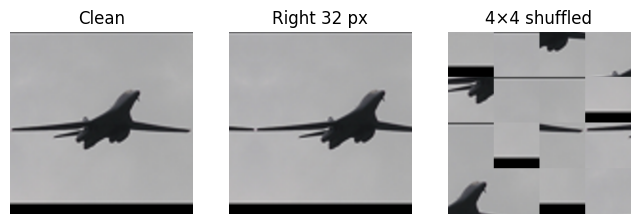

In [ ]:
def translate(im,delta,direction):
    if delta==0: return im.copy()
    p=np.pad(im,((delta,delta),(delta,delta),(0,0)),mode='reflect')
    sy,sx={'right':(delta,0),'left':(delta,2*delta),
           'down':(0,delta),'up':(2*delta,delta)}[direction]
    return np.ascontiguousarray(p[sy:sy+224,sx:sx+224])
DIRECTIONS=['right','left','down','up']
assert np.array_equal(translate(X[0],0,'right'),X[0])
def shuffle_patches(im,permutation):
    patches=im.reshape(4,56,4,56,3).transpose(0,2,1,3,4).reshape(16,56,56,3)
    return np.ascontiguousarray(patches[permutation].reshape(4,4,56,56,3).transpose(0,2,1,3,4).reshape(224,224,3))
rng=np.random.default_rng(SEED); perms=[]
for _ in range(len(X)):
    p=rng.permutation(16)
    while np.array_equal(p,np.arange(16)): p=rng.permutation(16)
    perms.append(p)
perms=np.array(perms)
PATCH=np.stack([shuffle_patches(im,p) for im,p in zip(X,perms)])
assert all(np.array_equal(np.sort(PATCH[i].reshape(-1,3),axis=0),np.sort(X[i].reshape(-1,3),axis=0)) for i in range(2))
np.save(OUT/'patch_permutations.npy',perms)
fig,ax=plt.subplots(1,3,figsize=(8,3))
for a,z,title in zip(ax,[X[0],translate(X[0],32,'right'),PATCH[0]],['Clean','Right 32 px','4×4 shuffled']):
    a.imshow(z); a.set_title(title); a.axis('off')
plt.show()

## 6. Evaluation of Interventions

In [ ]:
COLOR_FEATURES={}; CUE_FEATURES={}; PATCH_FEATURES={}; TRANS16={}; TRANS_CURVES=[]
def logits_for(m,feat):
    if m=='CLIP zero-shot': return scale*(feat@txt.T)
    w,b=HEADS[m]; return feat@w.T+b

def append_result(m,condition,feat,labels,reference):
    result=summarize(logits_for(m,feat),labels,reference)
    baseline=summarize(CLEAN_LOGITS[m],y)['accuracy']
    ROWS.append(dict(model=m,condition=condition,accuracy_change_pp=100*(result['accuracy']-baseline),**result))

CUE_DECISIONS=[]
for backbone in ['ResNet-50','ViT-B/16','CLIP head']:
    print('Evaluating',backbone)
    model=make_model(backbone)
    fgray=features(model,backbone,GRAY); fhue=features(model,backbone,HUE)
    fcue=features(model,backbone,CUE)
    COLOR_FEATURES[backbone]={'grayscale':fgray,'hue +90°':fhue}
    CUE_FEATURES[backbone]=fcue
    translated_16={}
    for delta in [8,16,32]:
        for direction in DIRECTIONS:
            ims=np.stack([translate(im,delta,direction) for im in X])
            fd=features(model,backbone,ims)
            if delta==16: translated_16[direction]=fd
            for m in ([backbone,'CLIP zero-shot'] if backbone=='CLIP head' else [backbone]):
                z=summarize(logits_for(m,fd),y,PRED_CLEAN[m])
                TRANS_CURVES.append(dict(model=m,pixels=delta,direction=direction,accuracy=z['accuracy'],consistency=z['consistency']))
            del ims,fd
    TRANS16[backbone]=translated_16
    fpatch=features(model,backbone,PATCH)
    PATCH_FEATURES[backbone]=fpatch
    for m in ([backbone,'CLIP zero-shot'] if backbone=='CLIP head' else [backbone]):
        append_result(m,'grayscale',fgray,y,PRED_CLEAN[m])
        append_result(m,'hue +90°',fhue,y,PRED_CLEAN[m])
        append_result(m,'patch shuffle',fpatch,y,PRED_CLEAN[m])
        preds=probs(logits_for(m,fcue)).argmax(1)
        for ix,pred in enumerate(preds):
            CUE_DECISIONS.append(dict(model=m,candidate_id=int(ACCEPTED_CANDIDATE[ix]),
                content_id=int(CUE_CONTENT[ix]),style_id=int(accepted.style_id.iloc[ix]),
                content_label=CLASSES[CUE_SHAPE[ix]],texture_label=CLASSES[CUE_TEXTURE[ix]],
                prediction=CLASSES[pred],decision='shape' if pred==CUE_SHAPE[ix] else 'texture' if pred==CUE_TEXTURE[ix] else 'other'))
    del model
    gc.collect(); torch.cuda.empty_cache()
print('Evaluation complete.')

Evaluating ResNet-50
Evaluating ViT-B/16
Evaluating CLIP head
Evaluation complete.


### Results

In [ ]:
performance=pd.DataFrame(ROWS)
performance['accuracy_change_pp']=performance['accuracy_change_pp'].fillna(0)
performance.to_csv(OUT/'performance.csv',index=False)
show_table(performance[['model','condition','accuracy','accuracy_change_pp','macro_f1','mean_max_confidence','consistency']].round(4))
print('Accuracy change is in percentage points; consistency compares predictions with the same clean image.')

,model,condition,accuracy,accuracy_change_pp,macro_f1,mean_max_confidence,consistency
0,ResNet-50,clean,0.974,0.0,0.9741,0.9091,NaN
1,ViT-B/16,clean,0.974,0.0,0.9739,0.9694,NaN
2,CLIP head,clean,0.984,0.0,0.9840,0.2150,NaN
3,CLIP zero-shot,clean,0.980,0.0,0.9799,0.9548,NaN
4,ResNet-50,grayscale,0.956,-1.8,0.9559,0.9126,0.962
5,ResNet-50,hue +90°,0.930,-4.4,0.9298,0.8941,0.940
6,ResNet-50,patch shuffle,0.882,-9.2,0.8827,0.8773,0.898
7,ViT-B/16,grayscale,0.952,-2.2,0.9520,0.9654,0.952
8,ViT-B/16,hue +90°,0.940,-3.4,0.9399,0.9419,0.944
9,ViT-B/16,patch shuffle,0.894,-8.0,0.8927,0.9093,0.898


Accuracy change is in percentage points; consistency compares predictions with the same clean image.


### Shape vs Texture

,model,shape,texture,other,total,shape_bias_pct,coverage_pct
0,ResNet-50,153,23,24,200,86.93,88.0
1,ViT-B/16,171,13,16,200,92.93,92.0
2,CLIP head,180,10,10,200,94.74,95.0
3,CLIP zero-shot,178,10,12,200,94.68,94.0


decision                                    other  shape  texture
model          content_label texture_label                       
CLIP head      airplane      ship               0     20        0
               bird          cat                0     20        0
               car           truck              0     17        3
               cat           bird               4     14        2
               deer          horse              1     18        1
               dog           monkey             3     15        2
               horse         deer               0     18        2
               monkey        dog                2     18        0
               ship          airplane           0     20        0
               truck         car                0     20        0
CLIP zero-shot airplane      ship               1     19        0
               bird          cat                0     20        0
               car           truck              0     16        4
               cat           bird               5     13        2
               deer          horse              2     17        1
               dog           monkey             1     18        1
               horse         deer               1     19        0
               monkey        dog                1     18        1
               ship          airplane           0     20        0
               truck         car                1     18        1
ResNet-50      airplane      ship               2     13        5
               bird          cat                1     18        1
               car           truck              0     20        0
               cat           bird               4      8        8
               deer          horse              1     18        1
               dog           monkey             7     13        0
               horse         deer               0     13        7
               monkey        dog                4     16        0
               ship          airplane           2     18        0
               truck         car                3     16        1
ViT-B/16       airplane      ship               0     19        1
               bird          cat                0     19        1
               car           truck              0     19        1
               cat           bird               5     12        3
               deer          horse              0     19        1
               dog           monkey             8     11        1
               horse         deer               1     17        2
               monkey        dog                1     19        0
               ship          airplane           0     19        1
               truck         car                1     17        2

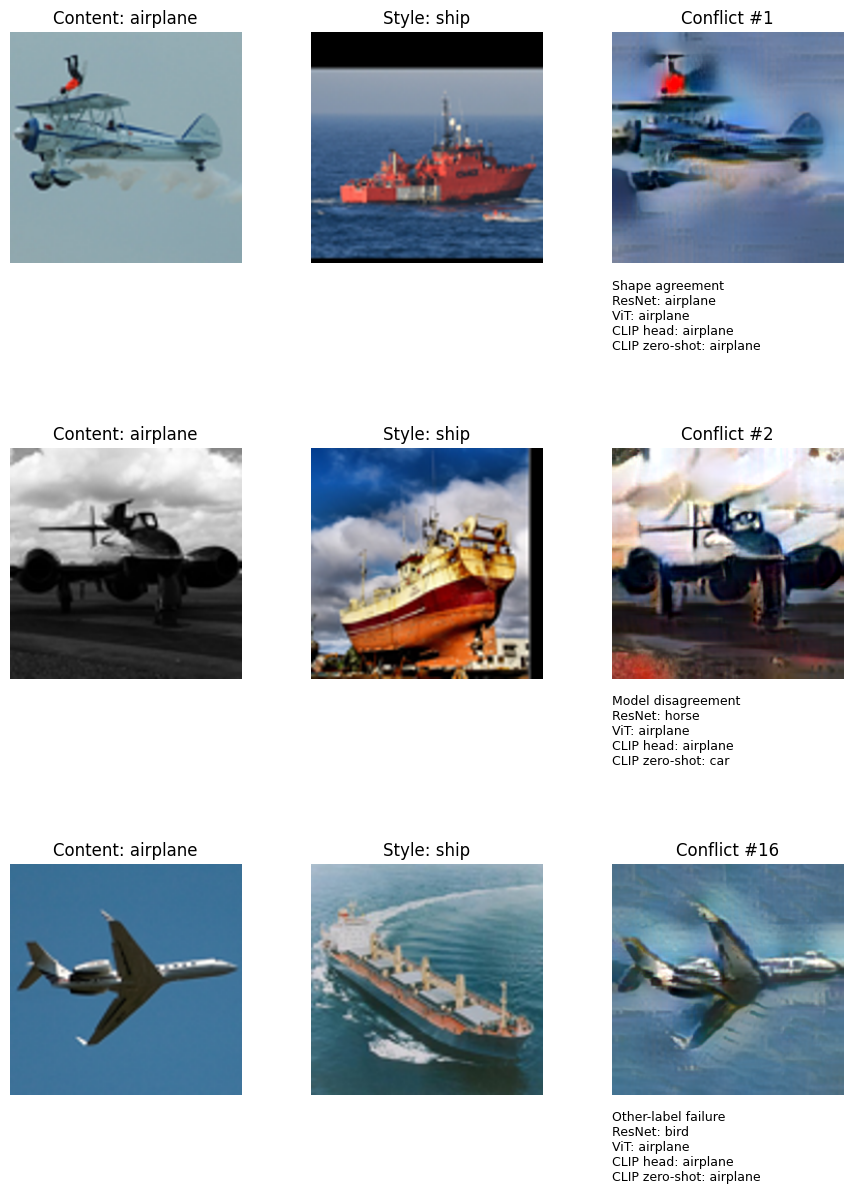

In [ ]:
cue_df=pd.DataFrame(CUE_DECISIONS); cue_df.to_csv(OUT/'cue_predictions.csv',index=False)
shape_rows=[]
for m,g in cue_df.groupby('model',sort=False):
    z=g.decision.value_counts(); ns=int(z.get('shape',0)); nt=int(z.get('texture',0)); no=int(z.get('other',0))
    shape_rows.append(dict(model=m,shape=ns,texture=nt,other=no,total=len(g),
        shape_bias_pct=100*ns/(ns+nt) if ns+nt else np.nan,coverage_pct=100*(ns+nt)/len(g)))
shape_table=pd.DataFrame(shape_rows);shape_table.to_csv(OUT/'shape_bias.csv',index=False)
show_table(shape_table.round(2))
assert (shape_table[['shape','texture','other']].sum(axis=1)==shape_table.total).all()
show_table(cue_df.groupby(['model','content_label','texture_label','decision']).size().rename('n').unstack(fill_value=0))


piv = cue_df.pivot(index='candidate_id', columns='model', values='decision')

cases = [
    ('Shape agreement', (piv == 'shape').all(axis=1)),
    ('Model disagreement', piv.nunique(axis=1) > 1),
    ('Other-label failure', (piv == 'other').any(axis=1)),
]

examples, used = [], set()
for title, mask in cases:
    ids = [int(cid) for cid in piv.index[mask] if int(cid) not in used]
    if ids:
        examples.append((title, ids[0]))
        used.add(ids[0])

fig, axes = plt.subplots(
    len(examples), 3, figsize=(11, 4.6 * len(examples)), squeeze=False
)

short_names = {
    'ResNet-50': 'ResNet',
    'ViT-B/16': 'ViT',
    'CLIP head': 'CLIP head',
    'CLIP zero-shot': 'CLIP zero-shot',
}

for row, (title, cid) in enumerate(examples):
    r = review.loc[review.candidate_id == cid].iloc[0]
    images = [
        (X[int(r.content_id)], f'Content: {r.content_class}'),
        (X[int(r.style_id)], f'Style: {r.style_class}'),
        (CAND[cid], f'Conflict #{cid}'),
    ]
    for col, (img, label) in enumerate(images):
        axes[row, col].imshow(img)
        axes[row, col].set_title(label)
        axes[row, col].axis('off')

    predictions = (
        cue_df[cue_df.candidate_id == cid]
        .set_index('model')['prediction']
        .to_dict()
    )
    label = title + '\n' + '\n'.join(
        f'{short_names[m]}: {predictions[m]}' for m in NAMES
    )
    axes[row, 2].text(
        0, -0.07, label, transform=axes[row, 2].transAxes,
        ha='left', va='top', fontsize=9, clip_on=False
    )

fig.subplots_adjust(hspace=0.8)
plt.savefig(OUT / 'cue_examples.png', dpi=160, bbox_inches='tight')
plt.show()

### Translation

,model,pixels,accuracy,consistency
0,CLIP head,0,0.9840,1.0000
1,CLIP head,8,0.9840,0.9920
2,CLIP head,16,0.9790,0.9850
3,CLIP head,32,0.9730,0.9850
4,CLIP zero-shot,0,0.9800,1.0000
5,CLIP zero-shot,8,0.9780,0.9865
6,CLIP zero-shot,16,0.9770,0.9830
7,CLIP zero-shot,32,0.9665,0.9825
8,ResNet-50,0,0.9740,1.0000
9,ResNet-50,8,0.9730,0.9930


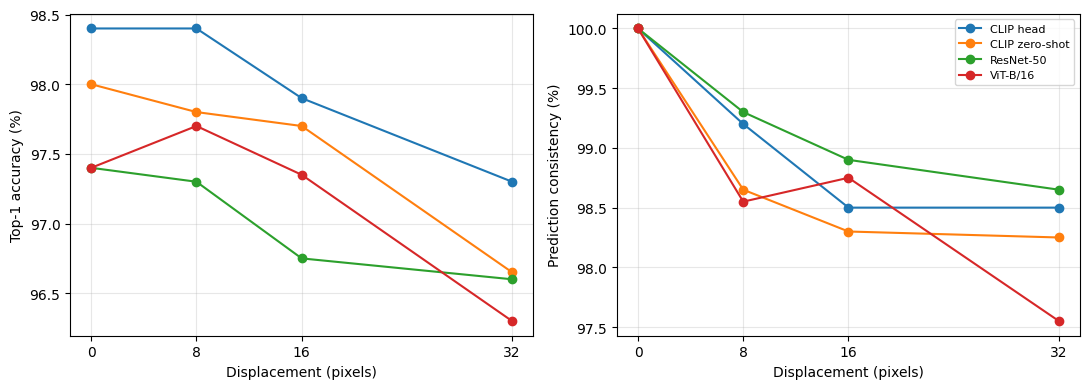

In [ ]:
curves=pd.DataFrame(TRANS_CURVES)
for m in NAMES:
    baseline=summarize(CLEAN_LOGITS[m],y)
    curves.loc[len(curves)]=dict(model=m,pixels=0,direction='all',accuracy=baseline['accuracy'],consistency=1.0)
curves.to_csv(OUT/'translation_by_direction.csv',index=False)
mean_curve=curves.groupby(['model','pixels'],as_index=False)[['accuracy','consistency']].mean()
mean_curve.to_csv(OUT/'translation_mean.csv',index=False)
show_table(mean_curve.round(4))
fig,axes=plt.subplots(1,2,figsize=(11,4))
for m,g in mean_curve.groupby('model'):
    g=g.sort_values('pixels')
    for a,metric in zip(axes,['accuracy','consistency']): a.plot(g.pixels,100*g[metric],marker='o',label=m)
for a,title in zip(axes,['Top-1 accuracy','Prediction consistency']):
    a.set(xlabel='Displacement (pixels)',ylabel=title+' (%)',xticks=[0,8,16,32]);a.grid(alpha=.3)
axes[1].legend(fontsize=8);plt.tight_layout();plt.savefig(OUT/'translation.png',dpi=160);plt.show()

## 7. Representation analysis

In [ ]:
def cosine_mean(a,b):
    a=F.normalize(torch.from_numpy(a).float(),dim=1)
    b=F.normalize(torch.from_numpy(b).float(),dim=1)
    return (a*b).sum(1).mean().item()
STABILITY=[]
for m in ['ResNet-50','ViT-B/16','CLIP head']:
    fc=CLEAN_FEATURES[m]
    for name,z in [('grayscale',COLOR_FEATURES[m]['grayscale']),('cue conflict',CUE_FEATURES[m]),
                   ('patch shuffle',PATCH_FEATURES[m])]:
        base=fc[CUE_CONTENT] if name=='cue conflict' else fc
        STABILITY.append(dict(backbone=m,intervention=name,n=len(z),mean_cosine=cosine_mean(base,z)))
    for d,z in TRANS16[m].items():
        STABILITY.append(dict(backbone=m,intervention=f'translation 16 px {d}',n=len(z),mean_cosine=cosine_mean(fc,z)))
    STABILITY.append(dict(backbone=m,intervention='translation 16 px, four-direction mean',n=4*len(fc),
                          mean_cosine=np.mean([cosine_mean(fc,z) for z in TRANS16[m].values()])))
stability=pd.DataFrame(STABILITY);stability.to_csv(OUT/'representation_stability.csv',index=False)
show_table(stability.round(4))

,backbone,intervention,n,mean_cosine
0,ResNet-50,grayscale,500,0.7885
1,ResNet-50,cue conflict,200,0.5442
2,ResNet-50,patch shuffle,500,0.7150
3,ResNet-50,translation 16 px right,500,0.9440
4,ResNet-50,translation 16 px left,500,0.9608
5,ResNet-50,translation 16 px down,500,0.9493
6,ResNet-50,translation 16 px up,500,0.9559
7,ResNet-50,"translation 16 px, four-direction mean",2000,0.9525
8,ViT-B/16,grayscale,500,0.7393
9,ViT-B/16,cue conflict,200,0.5772


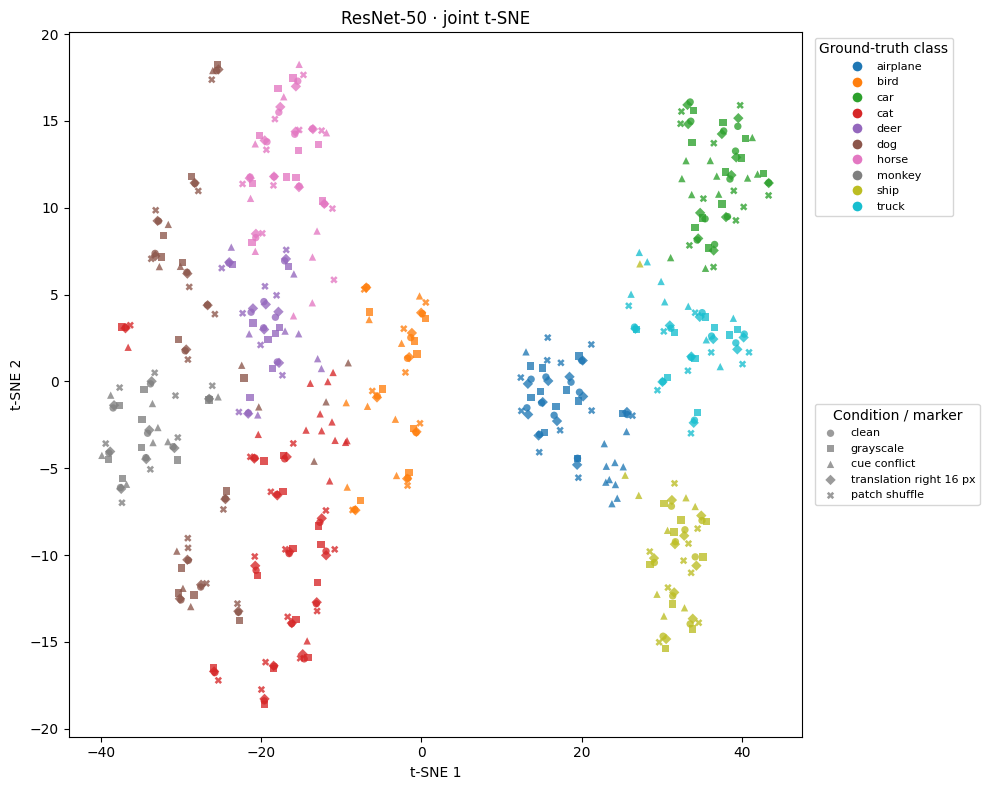

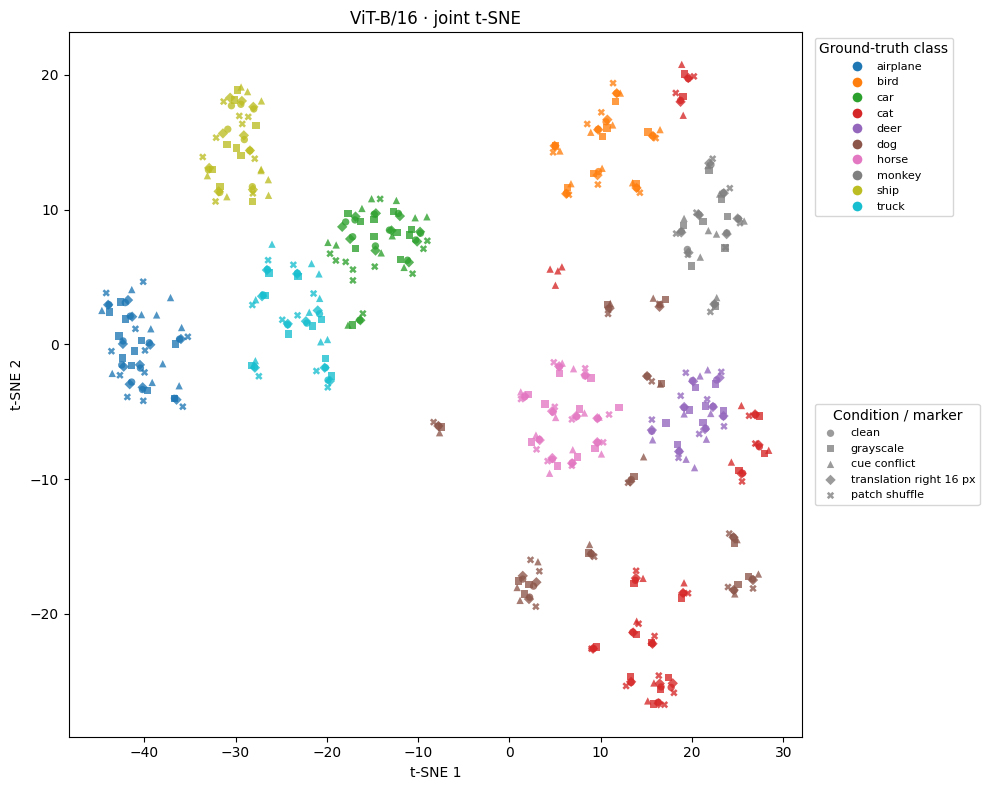

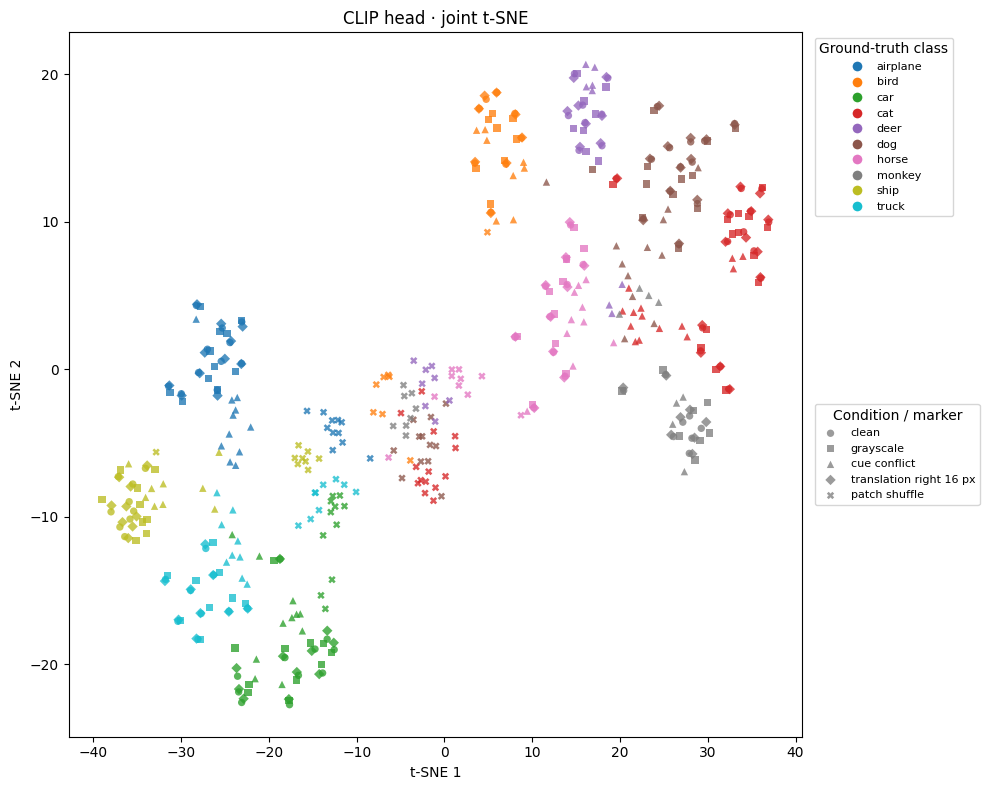

Settings: t-SNE, cosine metric, normalized input vectors, perplexity 30, PCA init, learning rate auto, seed 6304; 100 exact matched images per condition. Projection coordinates across backbones are not comparable.


In [ ]:
rng=np.random.default_rng(SEED)
vis_rows=rng.choice(np.arange(len(accepted)),VIS_N,replace=False)
vis_ids=CUE_CONTENT[vis_rows]; vis_labels=y[vis_ids]
assert len(np.unique(vis_ids))==VIS_N, 'Expected unique content images (disjoint class pairs).'
np.savez(OUT/'visualization_ids.npz',content_id=vis_ids,candidate_id=ACCEPTED_CANDIDATE[vis_rows],labels=vis_labels)
for m in ['ResNet-50','ViT-B/16','CLIP head']:
    conditions={'clean':CLEAN_FEATURES[m][vis_ids],
                'grayscale':COLOR_FEATURES[m]['grayscale'][vis_ids],
                'cue conflict':CUE_FEATURES[m][vis_rows],
                'translation right 16 px':TRANS16[m]['right'][vis_ids],
                'patch shuffle':PATCH_FEATURES[m][vis_ids]}
    Z=np.concatenate(list(conditions.values())).astype(np.float32)
    Z=F.normalize(torch.from_numpy(Z),dim=1).numpy()
    emb=TSNE(n_components=2,perplexity=30,metric='cosine',init='pca',learning_rate='auto',
             random_state=SEED).fit_transform(Z)
    fig,ax=plt.subplots(figsize=(10,8)); markers=['o','s','^','D','X'];
    cmap=plt.get_cmap('tab10')
    for ci,(condition,marker) in enumerate(zip(conditions,markers)):
        points=emb[ci*VIS_N:(ci+1)*VIS_N]
        ax.scatter(points[:,0],points[:,1],c=[cmap(int(v)) for v in vis_labels],
                   s=28,marker=marker,alpha=.78,label=condition,edgecolors='none')
    handles=[plt.Line2D([0],[0],marker='o',color='w',markerfacecolor=cmap(i),markersize=8,label=label) for i,label in enumerate(CLASSES)]
    leg=ax.legend(handles=handles,title='Ground-truth class',bbox_to_anchor=(1.01,1),loc='upper left',fontsize=8)
    ax.add_artist(leg);ax.legend(title='Condition / marker',bbox_to_anchor=(1.01,.48),loc='upper left',fontsize=8)
    ax.set(title=f'{m} · joint t-SNE',xlabel='t-SNE 1',ylabel='t-SNE 2')
    plt.tight_layout();plt.savefig(OUT/(m.replace('/','_').replace(' ','_')+'_tsne.png'),dpi=170,bbox_inches='tight');plt.show()
    pd.DataFrame({'x':emb[:,0],'y':emb[:,1],'condition':np.repeat(list(conditions),VIS_N),
                  'content_id':np.tile(vis_ids,len(conditions)),'class_id':np.tile(vis_labels,len(conditions))}).to_csv(
                      OUT/(m.replace('/','_').replace(' ','_')+'_tsne.csv'),index=False)
print('Settings: t-SNE, cosine metric, normalized input vectors, perplexity 30, PCA init, learning rate auto, seed 6304; 100 exact matched images per condition. Projection coordinates across backbones are not comparable.')

In [ ]:
per_class = pd.DataFrame({
    'class': CLASSES,
    'n': [int((y == c).sum()) for c in range(10)],
    **{
        model: [
            float((PRED_CLEAN[model][y == c] == c).mean())
            for c in range(10)
        ]
        for model in NAMES
    },
})
display(per_class.round(3))
per_class.to_csv(OUT / 'per_class_clean_accuracy.csv', index=False)

,class,n,ResNet-50,ViT-B/16,CLIP head,CLIP zero-shot
0,airplane,50,1.00,1.00,1.00,1.00
1,bird,50,0.94,0.98,0.98,0.98
2,car,50,0.98,0.98,0.98,0.98
3,cat,50,0.94,1.00,0.96,0.90
4,deer,50,0.98,0.94,0.98,0.98
5,dog,50,0.94,0.92,0.96,0.98
6,horse,50,0.98,0.94,1.00,1.00
7,monkey,50,0.98,1.00,1.00,1.00
8,ship,50,1.00,1.00,1.00,1.00
9,truck,50,1.00,0.98,0.98,0.98


In [ ]:
from google.colab import drive
from datetime import datetime, timezone
from pathlib import Path
import csv
import shutil

drive.mount('/content/drive')

source = Path('/content/task1_results')
required = [
    'config.json', 'selected_test_ids.csv', 'cue_review.csv',
    'cue_accepted_ids.csv', 'performance.csv', 'shape_bias.csv',
    'representation_stability.csv', 'per_class_clean_accuracy.csv',
]
missing = [name for name in required if not (source / name).is_file()]
assert not missing, f'Missing results: {missing}'

parent = Path('/content/drive/MyDrive/ATML_PA1/Task1_STL10')
stamp = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S_UTC')
destination = parent / stamp
destination.mkdir(parents=True, exist_ok=False)

def folder_for(path):
    name = path.name
    if path.parent.name == 'cue_contact_sheets' or path.suffix.lower() == '.png':
        return 'figures'
    if name.endswith('_head.pt'):
        return 'linear_heads'
    if name in {'vgg_normalised.pth', 'decoder.pth'}:
        return 'style_transfer_weights'
    if name in {'clean_subset.npz', 'cue_candidates.npz'}:
        return 'image_arrays'
    if name.startswith('cue_'):
        return 'cue_review_and_results'
    if name in {'selected_test_ids.csv', 'train_val_ids.json',
                'patch_permutations.npy', 'visualization_ids.npz'}:
        return 'image_ids_and_settings'
    if name.endswith('_tsne.csv'):
        return 'tables'
    if name in {'config.json'}:
        return 'settings'
    if path.suffix.lower() == '.csv':
        return 'tables'
    return 'other'

manifest = []
for file in sorted(source.rglob('*')):
    if not file.is_file():
        continue
    relative = file.relative_to(source)
    target = destination / folder_for(file) / relative
    target.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(file, target)
    assert target.stat().st_size == file.stat().st_size
    manifest.append((str(relative), str(target.relative_to(destination)), file.stat().st_size))

with (destination / 'file_manifest.csv').open('w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['original_path', 'drive_path', 'bytes'])
    writer.writerows(manifest)

print(f'Saved {len(manifest)} result files to:')
print(destination)
print(f'Total: {sum(row[2] for row in manifest) / 1e9:.2f} GB')

Mounted at /content/drive
Saved 71 result files to:
/content/drive/MyDrive/ATML_PA1/Task1_STL10/20260924_203148_UTC
Total: 0.21 GB
